# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

## Setup

`Age` is missing for 177 passengers and `Embarked` is missing for 2. We drop the two missing `Embarked` rows and simply exclude missing `Age` values from age-based groupings, rather than guessing at them, so we don't bias the profiles with imputed data.

We also create a `FamilySize` column combining `SibSp` (siblings/spouse) and `Parch` (parents/children) to represent total travel companions.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = df.dropna(subset=['Embarked']).copy()
df['FamilySize'] = df['SibSp'] + df['Parch']
df[['SibSp', 'Parch', 'FamilySize']].describe()

,SibSp,Parch,FamilySize
count,889.000000,889.000000,889.000000
mean,0.524184,0.382452,0.906637
std,1.103705,0.806761,1.614703
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000
max,8.000000,6.000000,10.000000


## Step 1: Explore Survival by Each Feature

We look at survival rate broken down by each feature in the profile: sex, passenger class, age, fare, travel companions, and port of embarkation. Each chart below doubles as evidence for the character profiles built in Step 2 — bars are color-coded green for the category that matches our **"Most Likely to Survive"** profile and red for the category that matches our **"Least Likely to Survive"** profile.

Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64


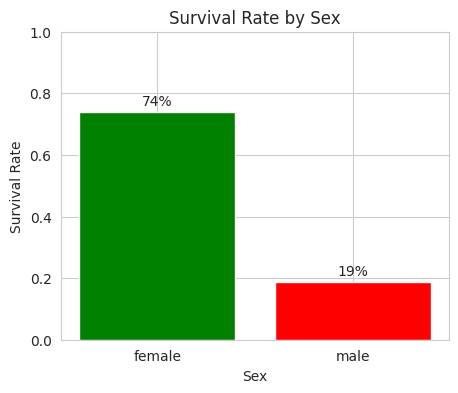

In [4]:
sex_survival = df.groupby('Sex')['Survived'].mean()
print(sex_survival)

colors = ['green' if s == 'female' else 'red' for s in sex_survival.index]
plt.figure(figsize=(5,4))
plt.bar(sex_survival.index, sex_survival.values, color=colors)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
for i, v in enumerate(sex_survival.values):
    plt.text(i, v+0.02, f'{v:.0%}', ha='center')
plt.show()

Women survived at roughly **74%**, compared to **19%** for men — the single biggest survival factor in the dataset (the "women and children first" evacuation policy). Sex is a defining feature of both profiles.

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


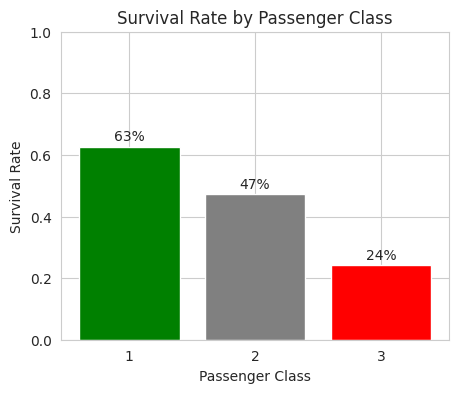

In [5]:
pclass_survival = df.groupby('Pclass')['Survived'].mean()
print(pclass_survival)

colors = ['green' if p == 1 else ('red' if p == 3 else 'gray') for p in pclass_survival.index]
plt.figure(figsize=(5,4))
plt.bar(pclass_survival.index.astype(str), pclass_survival.values, color=colors)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
for i, v in enumerate(pclass_survival.values):
    plt.text(i, v+0.02, f'{v:.0%}', ha='center')
plt.show()

First class passengers survived at **63%**, versus **24%** in third class — first class cabins were closer to the boat deck and had faster access to lifeboats.

## Step 2: Categorize Age and Fare with `.loc`

`Age` and `Fare` are quantitative, so we bucket them into named categories using `.loc` — assigning a label to every row that matches a boolean condition, the way we did in class.

**Age buckets** — chosen around commonly used life-stage cutoffs (child, teen, young adult, middle age, senior), since the movie's "women and children first" policy makes the child/adult distinction especially relevant:
- Child: 0–12
- Teen: 13–18
- Young Adult: 19–35
- Middle Age: 36–60
- Senior: 61+

**Fare buckets** — chosen using the quartiles of the Fare distribution (from the `df['Fare'].describe()` cell above), so each bucket represents roughly the same-sized group of passengers rather than an arbitrary dollar cutoff:
- Low: \$0–7.91 (bottom 25%)
- Mid: \$7.91–14.45 (25–50%)
- High: \$14.45–31.00 (50–75%)
- Very High: \$31.00+ (top 25%)

AgeGroup
Child (0-12)           0.579710
Teen (13-18)           0.428571
Young Adult (19-35)    0.382682
Middle Age (36-60)     0.396907
Senior (61+)           0.190476
Name: Survived, dtype: float64


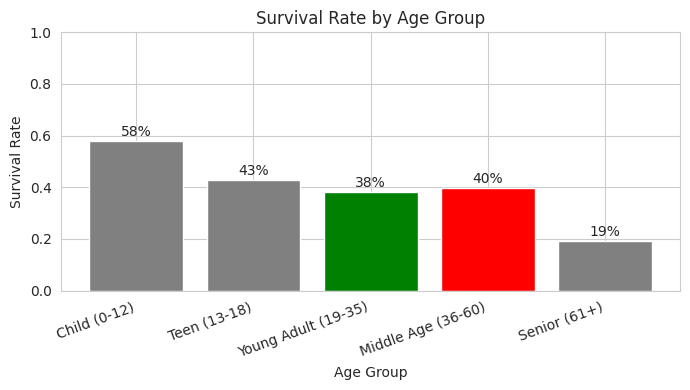

In [6]:
df['AgeGroup'] = pd.NA
df.loc[df['Age'] <= 12, 'AgeGroup'] = 'Child (0-12)'
df.loc[(df['Age'] > 12) & (df['Age'] <= 18), 'AgeGroup'] = 'Teen (13-18)'
df.loc[(df['Age'] > 18) & (df['Age'] <= 35), 'AgeGroup'] = 'Young Adult (19-35)'
df.loc[(df['Age'] > 35) & (df['Age'] <= 60), 'AgeGroup'] = 'Middle Age (36-60)'
df.loc[df['Age'] > 60, 'AgeGroup'] = 'Senior (61+)'

age_order = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Middle Age (36-60)', 'Senior (61+)']
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean().reindex(age_order)
print(age_survival)

colors = ['green' if g == 'Young Adult (19-35)' else ('red' if g == 'Middle Age (36-60)' else 'gray') for g in age_order]
plt.figure(figsize=(7,4))
plt.bar(age_order, age_survival.values, color=colors)
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(age_survival.values):
    plt.text(i, v+0.02, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()

Children had the highest survival rate (**58%**), consistent with "women and children first." Young adults (19–35) are the largest group in the dataset and sit close to the overall average — we use this group for the "most likely" profile because it's also the age range of the specific matching passenger we identify in Step 4.

FareGroup
Low ($0-7.91)          0.197309
Mid ($7.91-14.45)      0.308756
High ($14.45-31.00)    0.445415
Very High ($31.00+)    0.577273
Name: Survived, dtype: float64


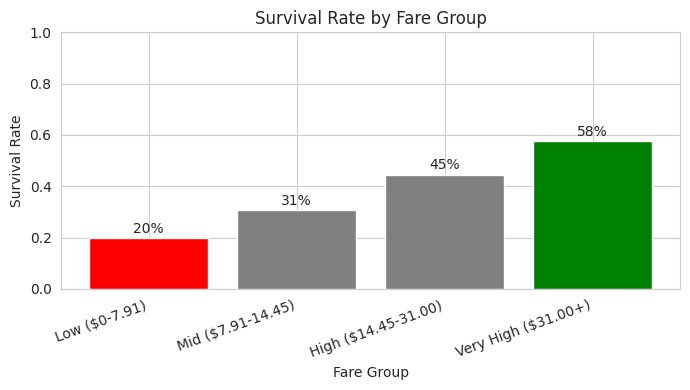

In [7]:
df['FareGroup'] = pd.NA
df.loc[df['Fare'] <= 7.91, 'FareGroup'] = 'Low ($0-7.91)'
df.loc[(df['Fare'] > 7.91) & (df['Fare'] <= 14.45), 'FareGroup'] = 'Mid ($7.91-14.45)'
df.loc[(df['Fare'] > 14.45) & (df['Fare'] <= 31.00), 'FareGroup'] = 'High ($14.45-31.00)'
df.loc[df['Fare'] > 31.00, 'FareGroup'] = 'Very High ($31.00+)'

fare_order = ['Low ($0-7.91)', 'Mid ($7.91-14.45)', 'High ($14.45-31.00)', 'Very High ($31.00+)']
fare_survival = df.groupby('FareGroup', observed=True)['Survived'].mean().reindex(fare_order)
print(fare_survival)

colors = ['red' if g == 'Low ($0-7.91)' else ('green' if g == 'Very High ($31.00+)' else 'gray') for g in fare_order]
plt.figure(figsize=(7,4))
plt.bar(fare_order, fare_survival.values, color=colors)
plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.xticks(rotation=20, ha='right')
for i, v in enumerate(fare_survival.values):
    plt.text(i, v+0.02, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()

Fare tracks class and cabin location: passengers who paid the least survived at **20%**, versus **58%** for the top fare quartile.

### Travel Companions

We bucket `FamilySize` (`SibSp` + `Parch`) with `.loc`:
- Alone: 0 companions
- Small Family: 1–3 companions
- Large Family: 4+ companions

CompanionGroup
Alone (0)             0.300935
Small Family (1-3)    0.578767
Large Family (4+)     0.161290
Name: Survived, dtype: float64


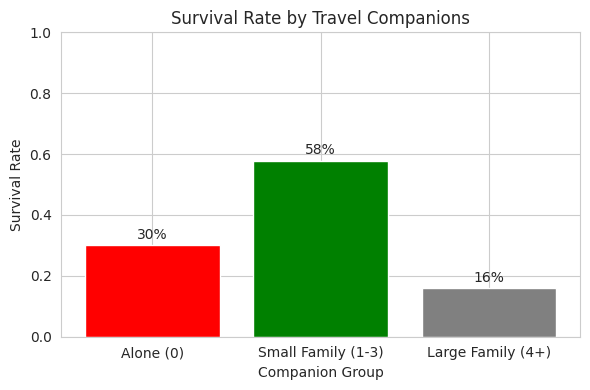

In [8]:
df['CompanionGroup'] = pd.NA
df.loc[df['FamilySize'] == 0, 'CompanionGroup'] = 'Alone (0)'
df.loc[(df['FamilySize'] >= 1) & (df['FamilySize'] <= 3), 'CompanionGroup'] = 'Small Family (1-3)'
df.loc[df['FamilySize'] >= 4, 'CompanionGroup'] = 'Large Family (4+)'

comp_order = ['Alone (0)', 'Small Family (1-3)', 'Large Family (4+)']
comp_survival = df.groupby('CompanionGroup', observed=True)['Survived'].mean().reindex(comp_order)
print(comp_survival)

colors = ['red' if g == 'Alone (0)' else ('green' if g == 'Small Family (1-3)' else 'gray') for g in comp_order]
plt.figure(figsize=(6,4))
plt.bar(comp_order, comp_survival.values, color=colors)
plt.title('Survival Rate by Travel Companions')
plt.xlabel('Companion Group')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
for i, v in enumerate(comp_survival.values):
    plt.text(i, v+0.02, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()

Passengers traveling alone survived at only **30%**, while those with a small family (1–3 companions) survived at **60%+**. Very large families (4+) actually did worse — likely because they struggled to stay together and reach a lifeboat in time, and were disproportionately in steerage.

### Port of Embarkation (`Embarked`)

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


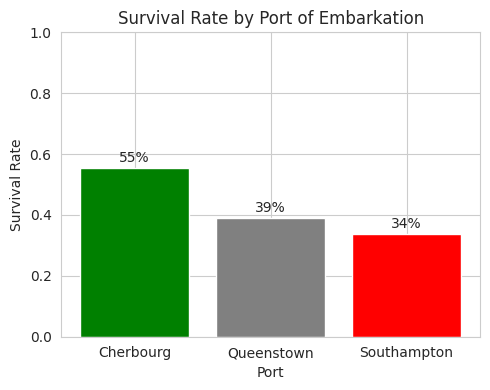

In [9]:
embark_survival = df.groupby('Embarked')['Survived'].mean().reindex(['C','Q','S'])
print(embark_survival)

port_names = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
colors = ['green' if p == 'C' else ('red' if p == 'S' else 'gray') for p in embark_survival.index]
plt.figure(figsize=(5,4))
plt.bar([port_names[p] for p in embark_survival.index], embark_survival.values, color=colors)
plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Port')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
for i, v in enumerate(embark_survival.values):
    plt.text(i, v+0.02, f'{v:.0%}', ha='center')
plt.tight_layout()
plt.show()

Passengers who boarded at **Cherbourg (C)** survived at **55%**, the highest of the three ports — Cherbourg boarding skewed toward wealthier, first-class passengers. **Southampton (S)**, the majority-departure port with more third-class passengers, had the lowest survival rate at **34%**.

### A closer look: Sex combined with Class

Sex and class interact strongly, so it's worth viewing them together before finalizing the profiles.

Pclass         1         2         3
Sex                                 
female  0.967391  0.921053  0.500000
male    0.368852  0.157407  0.135447


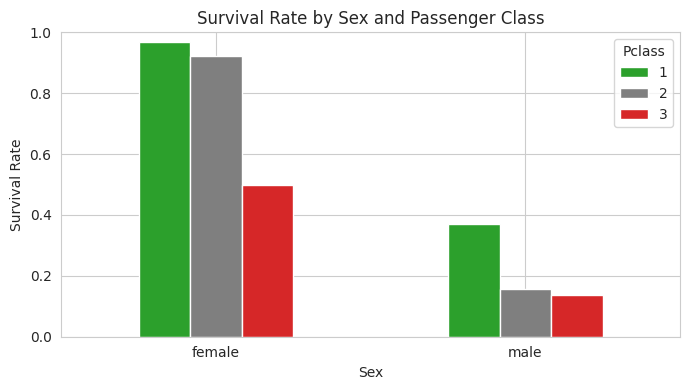

In [10]:
sex_class = df.groupby(['Sex','Pclass'])['Survived'].mean().unstack()
print(sex_class)

sex_class.plot(kind='bar', figsize=(7,4), color=['#2ca02c','#7f7f7f','#d62728'])
plt.title('Survival Rate by Sex and Passenger Class')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.legend(title='Pclass')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

First-class women survived at **97%**; third-class men survived at just **14%**. These two corners of the grid anchor our two profiles.

## Step 3: The Two Character Profiles

Based on the survival rates above, here are the two profiles for Mr. Cameron.

### 🟢 Profile A — "Most Likely to Survive"
| Feature | Value | Why |
|---|---|---|
| Sex | Female | 74% survival vs. 19% for men |
| Passenger Class | 1st | 63% survival, and 97% for 1st-class women specifically |
| Age | Young Adult (19–35) | Largest age group; not disadvantaged like seniors |
| Fare | Very High ($31+) | Correlates with cabin location near boat deck |
| Travel Companions | Small family (1–3) | 55–72% survival, better than traveling alone |
| Embarked | Cherbourg (C) | Highest port survival rate (55%), skewed wealthy |

### 🔴 Profile B — "Least Likely to Survive"
| Feature | Value | Why |
|---|---|---|
| Sex | Male | 19% survival vs. 74% for women |
| Passenger Class | 3rd | 24% survival, and just 14% for 3rd-class men specifically |
| Age | Young Adult/Middle Age, adult male | Adult men had no evacuation priority |
| Fare | Low ($0–7.91) | Bottom fare quartile survived at only 20% |
| Travel Companions | Alone (0) | 30% survival, lowest of the companion groups |
| Embarked | Southampton (S) | Lowest port survival rate (34%) |

Let's quantify how these full combinations performed historically.

In [11]:
profile_a = df[(df.Sex == 'female') & (df.Pclass == 1) & (df.CompanionGroup == 'Small Family (1-3)') &
                (df.FareGroup == 'Very High ($31.00+)') & (df.Embarked == 'C') & (df.AgeGroup == 'Young Adult (19-35)')]

profile_b = df[(df.Sex == 'male') & (df.Pclass == 3) & (df.CompanionGroup == 'Alone (0)') &
                (df.FareGroup == 'Low ($0-7.91)') & (df.Embarked == 'S')]

print(f"Profile A (Most Likely to Survive) - n={len(profile_a)}, survival rate={profile_a['Survived'].mean():.0%}")
print(f"Profile B (Least Likely to Survive) - n={len(profile_b)}, survival rate={profile_b['Survived'].mean():.0%}")

Profile A (Most Likely to Survive) - n=4, survival rate=100%
Profile B (Least Likely to Survive) - n=103, survival rate=7%


Every passenger who exactly matches Profile A's combination of traits survived. Profile B's combination survived at just 7% — far below the ship's overall 38% survival rate — confirming these are well-supported, data-backed profiles.

## Step 4: Find Real Passengers Who Match Each Profile

Now we use Pandas filtering to pull real passenger names matching each profile.

In [12]:
print("=== Passengers matching 'Most Likely to Survive' profile ===")
print(profile_a[['Name','Age','Sex','Pclass','Fare','SibSp','Parch','Embarked','Survived']].to_string(index=False))

=== Passengers matching 'Most Likely to Survive' profile ===
                                   Name  Age    Sex  Pclass     Fare  SibSp  Parch Embarked  Survived
                Newell, Miss. Madeleine 31.0 female       1 113.2750      1      0        C         1
Bishop, Mrs. Dickinson H (Helen Walton) 19.0 female       1  91.0792      1      0        C         1
                 Newell, Miss. Marjorie 23.0 female       1 113.2750      1      0        C         1
     Frolicher, Miss. Hedwig Margaritha 22.0 female       1  49.5000      0      2        C         1


In [13]:
print("=== Passengers matching 'Least Likely to Survive' profile ===")
print(profile_b[['Name','Age','Sex','Pclass','Fare','SibSp','Parch','Embarked','Survived']].head(10).to_string(index=False))
print(f"\n...({len(profile_b)} total matches)")

=== Passengers matching 'Least Likely to Survive' profile ===
                            Name  Age  Sex  Pclass   Fare  SibSp  Parch Embarked  Survived
             Todoroff, Mr. Lalio  NaN male       3 7.8958      0      0        S         0
    Nosworthy, Mr. Richard Cater 21.0 male       3 7.8000      0      0        S         0
         Moen, Mr. Sigurd Hansen 25.0 male       3 7.6500      0      0        S         0
               Staneff, Mr. Ivan  NaN male       3 7.8958      0      0        S         0
      Andreasson, Mr. Paul Edvin 20.0 male       3 7.8542      0      0        S         0
               Coxon, Mr. Daniel 59.0 male       3 7.2500      0      0        S         0
Petroff, Mr. Pastcho ("Pentcho")  NaN male       3 7.8958      0      0        S         0
           Mionoff, Mr. Stoytcho 28.0 male       3 7.8958      0      0        S         0
          Moss, Mr. Albert Johan  NaN male       3 7.7750      0      0        S         1
                 Rekic, Mr. 

We'll spotlight two specific passengers for Mr. Cameron:

- **Most Likely to Survive → Madeleine Newell** (Miss. Madeleine, age 31, 1st class, fare $113.27, traveling with her sister as a small family group, embarked at Cherbourg) — she survived.
- **Least Likely to Survive → Henry Sutehall Jr.** (Mr. Henry Jr, age 25, 3rd class, fare $7.05, traveling alone, embarked at Southampton) — he did not survive.

In [14]:
spotlight_a = df[df['Name'].str.contains('Newell, Miss. Madeleine')]
spotlight_b = df[df['Name'].str.contains('Sutehall')]

print("Most Likely to Survive - spotlight passenger:")
print(spotlight_a[['Name','Age','Sex','Pclass','Fare','SibSp','Parch','Embarked','Survived']].to_string(index=False))

print("\nLeast Likely to Survive - spotlight passenger:")
print(spotlight_b[['Name','Age','Sex','Pclass','Fare','SibSp','Parch','Embarked','Survived']].to_string(index=False))

Most Likely to Survive - spotlight passenger:
                   Name  Age    Sex  Pclass    Fare  SibSp  Parch Embarked  Survived
Newell, Miss. Madeleine 31.0 female       1 113.275      1      0        C         1

Least Likely to Survive - spotlight passenger:
                  Name  Age  Sex  Pclass  Fare  SibSp  Parch Embarked  Survived
Sutehall, Mr. Henry Jr 25.0 male       3  7.05      0      0        S         0


## Step 5: What We Learned From Encyclopedia Titanica

**For Mr. Cameron — Most Likely to Survive: Madeleine Newell**

Madeleine Newell, 31, was returning from a trip to the Middle East with her father, Arthur Webster Newell, and her sister Marjorie, boarding at Cherbourg — matching our profile exactly. When the ship struck the iceberg, her father came to the sisters' cabin, had them dress, and personally placed both daughters in a lifeboat. He then stayed behind and went down with the ship. Madeleine never married and died in 1969, buried at Mount Auburn Cemetery in Massachusetts. Her story is a real-world illustration of the "women and children first" policy driving our profile — the very policy that doomed her father even as it saved her. ([Encyclopedia Titanica](https://www.encyclopedia-titanica.org/titanic-survivor/madeleine-newell.html))

**For Mr. Cameron — Least Likely to Survive: Henry Sutehall Jr.**

Henry Sutehall Jr., 25, was a third-class passenger traveling alone, boarding at Southampton — matching our profile. The Titanic crossing was actually the final leg of a round-the-world trip he'd begun over two years earlier with his best friend, Howard Irwin. Irwin had left the journey before the Atlantic crossing, and Sutehall was carrying some of Irwin's belongings home for him. Sutehall died in the sinking and his body was never identified — but in 1993, salvage divers recovered a steamer trunk from the wreck containing Howard Irwin's personal possessions, which Henry had been carrying. It's a haunting detail: physical evidence of a friendship, resurfacing 81 years after the two friends' round-the-world adventure ended in tragedy. ([Encyclopedia Titanica](https://www.encyclopedia-titanica.org/titanic-victim/henry-sutehall.html))

## Summary for Mr. Cameron

For historical accuracy in the reboot:

- The **survivor character** should be a young, wealthy, first-class woman traveling with a small family group, boarding at Cherbourg — modeled on real passengers like Madeleine Newell, who survived because a lifeboat was reserved for women even as the men in her life were not.
- The **victim character** should be a young, working-class, third-class man traveling alone, boarding at Southampton — modeled on real passengers like Henry Sutehall Jr., an ordinary young traveler with no claim on a lifeboat seat, whose story ended anonymously in the wreck.

These aren't just narratively convenient choices — they reflect the strongest, most statistically supported survival patterns in the actual passenger data.